In [1]:
import pandas as pd

df = pd.read_csv("../data/results.csv", parse_dates=["date"])
print(df.shape)  # how many rows (matches) and columns
df.head()  # peek at the first few matches

(49477, 9)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [2]:
df.shape

(49477, 9)

In [3]:
# Separate played matches from the 2026 fixtures (which have blank scores)
played = df.dropna(subset=["home_score", "away_score"]).copy()
unplayed = df[df["home_score"].isna()]
print("Played:", len(played), "| Future fixtures to predict:", len(unplayed))


# Derive our label by comparing the scores
def result(row):
    if row.home_score > row.away_score:
        return "home_win"
    if row.home_score < row.away_score:
        return "away_win"
    return "draw"


played["result"] = played.apply(result, axis=1)

# How often does each outcome happen?
print(played["result"].value_counts(normalize=True).round(3) * 100)

# Does playing at home actually matter?
print(played.groupby("neutral")["result"].apply(lambda s: (s == "home_win").mean()).round(3) * 100)

Played: 49417 | Future fixtures to predict: 60
result
home_win    49.0
away_win    28.3
draw        22.7
Name: proportion, dtype: float64
neutral
False    50.7
True     44.2
Name: result, dtype: float64


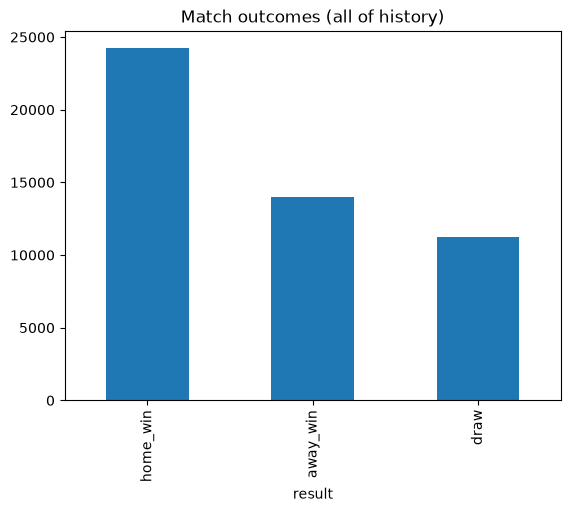

In [4]:
import matplotlib.pyplot as plt

played["result"].value_counts().plot(kind="bar", title="Match outcomes (all of history)")
plt.show()

In [5]:
from collections import defaultdict, deque

played = df.dropna(subset=["home_score", "away_score"]).sort_values("date").reset_index(drop=True)


def result(h, a):
    return "home_win" if h > a else "away_win" if h < a else "draw"


elo = defaultdict(lambda: 1500.0)  # every team starts at 1500
form = defaultdict(lambda: deque(maxlen=5))  # last 5 results' points
K = 30

rows = []
for r in played.itertuples():
    h, a = r.home_team, r.away_team
    eh, ea = elo[h], elo[a]
    fh = sum(form[h]) / len(form[h]) if form[h] else 1.5
    fa = sum(form[a]) / len(form[a]) if form[a] else 1.5
    res = result(r.home_score, r.away_score)

    # record features FIRST — using only what happened before this match
    rows.append(
        {
            "date": r.date,
            "home_team": h,
            "away_team": a,
            "elo_diff": eh - ea,
            "form_home": fh,
            "form_away": fa,
            "neutral": int(str(r.neutral).upper() == "TRUE"),
            "result": res,
        }
    )

    # THEN update ratings with the actual result (the leakage-safe order)
    s_home = 1.0 if res == "home_win" else 0.5 if res == "draw" else 0.0
    exp_home = 1 / (1 + 10 ** ((ea - eh) / 400))
    elo[h] = eh + K * (s_home - exp_home)
    elo[a] = ea + K * ((1 - s_home) - (1 - exp_home))
    form[h].append(3 if res == "home_win" else 1 if res == "draw" else 0)
    form[a].append(3 if res == "away_win" else 1 if res == "draw" else 0)

feat = pd.DataFrame(rows)
print(feat.shape)

(49417, 8)


In [6]:
feat = feat.sort_values("date")
cutoff = "2021-01-01"
train = feat[feat["date"] < cutoff]
test = feat[feat["date"] >= cutoff]
print("Train:", len(train), "| Test:", len(test))

train.to_csv("../data/train.csv", index=False)
test.to_csv("../data/test.csv", index=False)

Train: 43722 | Test: 5695


In [7]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss

train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

features = ["elo_diff", "form_home", "form_away", "neutral"]
Xtr, ytr = train[features], train["result"]
Xte, yte = test[features], test["result"]
classes = ["away_win", "draw", "home_win"]

# Baseline 1: always guess the majority class (home win)
acc_majority = (yte == "home_win").mean()

# Baseline 2: a hand rule — higher-Elo team wins. No learning at all.
acc_rule = accuracy_score(yte, np.where(Xte["elo_diff"] > 0, "home_win", "away_win"))

# Baseline 3: always output historical frequencies (a bar for log loss)
base = ytr.value_counts(normalize=True)
ll_base = log_loss(yte, np.tile([base[c] for c in classes], (len(yte), 1)), labels=classes)

# First ML model: logistic regression
clf = LogisticRegression(max_iter=1000).fit(Xtr, ytr)
acc_lr = accuracy_score(yte, clf.predict(Xte))
ll_lr = log_loss(yte, clf.predict_proba(Xte), labels=clf.classes_)

print(f"Accuracy | always-home {acc_majority:.1%} | Elo-rule {acc_rule:.1%} | LogReg {acc_lr:.1%}")
print(f"Log loss | base-rate {ll_base:.3f} | LogReg {ll_lr:.3f}")

Accuracy | always-home 48.0% | Elo-rule 60.0% | LogReg 60.8%
Log loss | base-rate 1.049 | LogReg 0.868


In [8]:
import mlflow
import xgboost

print("ready:", mlflow.__version__, xgboost.__version__)

ready: 3.13.0 3.2.0


In [9]:
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

mlflow.set_experiment("world-cup-predictor")

# Run 1: logistic regression
with mlflow.start_run(run_name="logistic_regression"):
    clf = LogisticRegression(max_iter=1000).fit(Xtr, ytr)
    mlflow.log_param("model", "logistic_regression")
    mlflow.log_metric("accuracy", accuracy_score(yte, clf.predict(Xte)))
    mlflow.log_metric("log_loss", log_loss(yte, clf.predict_proba(Xte), labels=clf.classes_))

# Run 2: XGBoost
le = LabelEncoder().fit(ytr)
params = dict(
    n_estimators=400, max_depth=4, learning_rate=0.03, subsample=0.9, colsample_bytree=0.9
)
with mlflow.start_run(run_name="xgboost"):
    xgb = XGBClassifier(**params, eval_metric="mlogloss").fit(Xtr, le.transform(ytr))
    for k, v in params.items():
        mlflow.log_param(k, v)
    mlflow.log_param("model", "xgboost")
    mlflow.log_metric("accuracy", accuracy_score(le.transform(yte), xgb.predict(Xte)))
    mlflow.log_metric("log_loss", log_loss(le.transform(yte), xgb.predict_proba(Xte)))

print("Both runs logged.")

Both runs logged.


In [10]:
import mlflow

runs = mlflow.search_runs(experiment_names=["world-cup-predictor"])
print(runs[["tags.mlflow.runName", "metrics.accuracy", "metrics.log_loss"]])

   tags.mlflow.runName  metrics.accuracy  metrics.log_loss
0              xgboost          0.607375          0.869513
1  logistic_regression          0.607726          0.867652
2              xgboost          0.607375          0.869513
3  logistic_regression          0.607726          0.867652


In [12]:
import warnings

import optuna

warnings.filterwarnings("ignore")

trainfull = pd.read_csv("../data/train.csv", parse_dates=["date"])
test = pd.read_csv("../data/test.csv", parse_dates=["date"])

# carve validation out of training, by date — test set stays untouched
tr = trainfull[trainfull["date"] < "2019-01-01"]
va = trainfull[trainfull["date"] >= "2019-01-01"]
F = ["elo_diff", "form_home", "form_away", "neutral"]
le = LabelEncoder().fit(trainfull["result"])
Xtr, ytr = tr[F], le.transform(tr["result"])
Xva, yva = va[F], le.transform(va["result"])
Xte, yte = test[F], le.transform(test["result"])


def objective(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 100, 600),
        max_depth=trial.suggest_int("max_depth", 2, 6),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 10),
    )
    m = XGBClassifier(**params, eval_metric="mlogloss").fit(Xtr, ytr)
    return log_loss(yva, m.predict_proba(Xva))  # score on VALIDATION, not test


optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=40)  # takes ~1 minute
print("best validation log_loss:", round(study.best_value, 4))

# now — and only now — judge on the test set, then log it
best = XGBClassifier(**study.best_params, eval_metric="mlogloss")
best.fit(pd.concat([Xtr, Xva]), np.concatenate([ytr, yva]))
ll = log_loss(yte, best.predict_proba(Xte))
acc = accuracy_score(yte, best.predict(Xte))
print(f"TUNED XGBoost on test: log_loss={ll:.4f}  accuracy={acc:.3f}")

with mlflow.start_run(run_name="xgboost_tuned"):
    mlflow.log_params(study.best_params)
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("log_loss", ll)

best validation log_loss: 0.8759
TUNED XGBoost on test: log_loss=0.8692  accuracy=0.607


In [13]:
from sklearn.metrics import classification_report, confusion_matrix

train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")
F = ["elo_diff", "form_home", "form_away", "neutral"]

clf = LogisticRegression(max_iter=1000).fit(train[F], train["result"])
pred = clf.predict(test[F])
proba = clf.predict_proba(test[F])
y = test["result"].values
labels = ["away_win", "draw", "home_win"]

# 1. Confusion matrix — actual vs predicted
print(
    pd.DataFrame(
        confusion_matrix(y, pred, labels=labels),
        index=["actual_" + l for l in labels],
        columns=["pred_" + l for l in labels],
    )
)
print("\nTimes the model predicted 'draw':", (pred == "draw").sum())

# 2. Per-class performance
print("\n", classification_report(y, pred, labels=labels, digits=3, zero_division=0))

# 3. Calibration of the home-win probability
hp = proba[:, list(clf.classes_).index("home_win")]
actual_home = y == "home_win"
print("Calibration — predicted home-win % vs what actually happened:")
for lo in [0, 0.2, 0.4, 0.6, 0.8]:
    m = (hp >= lo) & (hp < lo + 0.2)
    if m.sum():
        print(
            f"  {int(lo * 100):3d}-{int(lo * 100) + 20}%  ->  actual {actual_home[m].mean() * 100:5.1f}%  (n={m.sum()})"
        )

                 pred_away_win  pred_draw  pred_home_win
actual_away_win           1024          0            636
actual_draw                431          0            871
actual_home_win            296          0           2437

Times the model predicted 'draw': 0

               precision    recall  f1-score   support

    away_win      0.585     0.617     0.600      1660
        draw      0.000     0.000     0.000      1302
    home_win      0.618     0.892     0.730      2733

    accuracy                          0.608      5695
   macro avg      0.401     0.503     0.443      5695
weighted avg      0.467     0.608     0.525      5695

Calibration — predicted home-win % vs what actually happened:
    0-20%  ->  actual   8.9%  (n=844)
   20-40%  ->  actual  26.2%  (n=1104)
   40-60%  ->  actual  46.7%  (n=1436)
   60-80%  ->  actual  66.2%  (n=1486)
   80-100%  ->  actual  86.5%  (n=825)


In [14]:
import joblib

# train on everything we have (train + test) for the final production model
full = pd.concat([pd.read_csv("../data/train.csv"), pd.read_csv("../data/test.csv")])
F = ["elo_diff", "form_home", "form_away", "neutral"]
final_model = LogisticRegression(max_iter=1000).fit(full[F], full["result"])

joblib.dump(final_model, "../model.pkl")
print("Saved model.pkl")

Saved model.pkl
